# Enhancing Real Estate Investment Decisions with Predictive Modeling

## Machine Learning Based Residential Property Price Prediction

### Project Objective

The objective of this project is to develop a machine learning model that predicts residential property sale prices from property characteristics and identifies the variables that contribute most strongly to the predictions.

### Business Case

Surprise Housing is a US-based housing company planning to expand into a new real estate market. The company wants to use data-driven methods to support property valuation, investment screening, and pricing decisions.

The supplied dataset is based on the Ames Housing dataset and is used as the basis for developing and evaluating the predictive modeling framework. The dataset description identifies `Neighborhood` as physical locations within Ames city limits.

### Project Workflow

1. Data Collection and Preprocessing
2. Exploratory Data Analysis (EDA)
3. Feature Engineering
4. Model Selection and Training
5. Hyperparameter Tuning
6. Model Evaluation
7. Feature Importance Analysis
8. Business Implications
9. Final Prediction and Conclusion


## Project Overview

This project develops an end-to-end machine learning framework for residential property price prediction. The workflow covers data understanding, missing-value treatment, exploratory analysis, feature preparation, model development, model comparison, hyperparameter tuning, diagnostic evaluation, feature importance analysis, and prediction of unseen test properties.

The target variable is `SalePrice`. The main predictive information comes from property characteristics such as overall quality, living area, basement area, garage features, construction year, remodeling year, lot size, and neighborhood.

The final selected model is a tuned Gradient Boosting Regressor.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Scikit-learn:", sklearn.__version__)
print("All required libraries are working!")

Pandas: 0.25.3
NumPy: 1.19.2
Scikit-learn: 0.22.2.post1
All required libraries are working!


# 1. Introduction

Real estate investment decisions depend on accurately estimating property values and understanding the factors that influence those values. Predictive modeling can help real estate companies evaluate properties systematically and make more consistent, data-driven investment and pricing decisions.

This project is based on the business scenario of Surprise Housing, a US-based housing company planning to expand into a new real estate market. The objective is to develop a machine learning model capable of predicting residential property sale prices from a wide range of property characteristics.

The supplied dataset contains residential property attributes and sale prices from the Ames Housing dataset. These data are used as the basis for developing and evaluating the predictive modeling framework. The dataset should therefore not be described as an Australian housing dataset; the business case is the expansion scenario, while the supplied observations are Ames Housing data.

The project compares Linear Regression, Ridge Regression, Lasso Regression, Random Forest Regression, and Gradient Boosting Regression. Model performance is evaluated using Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R². The strongest model is then tuned using cross-validation and used to generate final test predictions.


# 2. Problem Statement

Surprise Housing wants to use data-driven techniques to support residential property valuation and investment decisions. The company needs a regression model that can estimate the sale price of a property from its available characteristics.

The project addresses the following objectives:

- Identify the important variables associated with residential property prices.
- Clean and preprocess numerical and categorical property information.
- Explore the distribution of prices and relationships among important variables.
- Develop and compare multiple regression algorithms.
- Tune the hyperparameters of the strongest initial model.
- Evaluate the final model using appropriate regression metrics and diagnostic plots.
- Interpret feature importance and coefficient directions.
- Generate predictions for unseen test properties.
- Translate model findings into practical business recommendations.


# 3. Data Collection and Preprocessing

## 3.1 Dataset Description

The project uses separate training and test datasets. The training dataset contains 1,168 observations and 81 columns, including the target variable `SalePrice`. The test dataset contains 292 observations and 80 columns and does not contain `SalePrice`.

The data include numerical and categorical property characteristics covering areas, rooms, quality ratings, construction and remodeling years, garages, basements, neighborhood, sale conditions, and other property attributes.

The `Id` column is treated as an identifier rather than a meaningful predictive variable and is therefore stored separately and removed from model training.


In [2]:
# Load the training and test datasets

train_path = "../data/Housing-project-train-data.csv"
test_path = "../data/Housing-project-test-data.csv"

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

print("Training dataset shape:", train.shape)
print("Testing dataset shape:", test.shape)


Training dataset shape: (1168, 81)
Testing dataset shape: (292, 80)


## 3.2 Missing Value Treatment

The dataset contains missing values in several categorical and numerical variables. Missing values are handled according to the meaning of each variable rather than using one generic imputation rule.

For categorical variables where a missing value represents the absence of a facility, the value `None` is used. For numerical variables where missingness represents the absence of a facility, the value `0` is used. `LotFrontage` is imputed using the training-set median. `GarageYrBlt` is set to `0` when no garage is present. The single missing `Electrical` value in the test data is filled using the training-set mode.

This approach preserves useful information contained in missingness. For example, the data dictionary explicitly defines `NA` as no pool for `PoolQC`, no garage for `GarageType`, and no basement for `BsmtQual`.


## 3.3 Initial Dataset Inspection

The dataset structure, first few observations, target variable, descriptive statistics, and column names are inspected before model preparation. This establishes the dimensions and data types of the problem and helps identify variables requiring special treatment.


In [3]:
train.head()


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,127,120,RL,NaN,4928,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2007,WD,Normal,128000
1,889,20,RL,95.0,15865,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,10,2007,WD,Normal,268000
2,793,60,RL,92.0,9920,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2007,WD,Normal,269790
3,110,20,RL,105.0,11751,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,1,2010,COD,Normal,190000
4,422,20,RL,NaN,16635,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2009,WD,Normal,215000


In [4]:
print("Target variable: SalePrice")
print("Data type:", train["SalePrice"].dtype)


Target variable: SalePrice
Data type: int64


In [5]:
print("Number of columns:", train.shape[1])
print("\nColumn names:")
print(train.columns.tolist())


Number of columns: 81

Column names:
['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch'

In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1168 entries, 0 to 1167
Data columns (total 81 columns):
Id               1168 non-null int64
MSSubClass       1168 non-null int64
MSZoning         1168 non-null object
LotFrontage      954 non-null float64
LotArea          1168 non-null int64
Street           1168 non-null object
Alley            77 non-null object
LotShape         1168 non-null object
LandContour      1168 non-null object
Utilities        1168 non-null object
LotConfig        1168 non-null object
LandSlope        1168 non-null object
Neighborhood     1168 non-null object
Condition1       1168 non-null object
Condition2       1168 non-null object
BldgType         1168 non-null object
HouseStyle       1168 non-null object
OverallQual      1168 non-null int64
OverallCond      1168 non-null int64
YearBuilt        1168 non-null int64
YearRemodAdd     1168 non-null int64
RoofStyle        1168 non-null object
RoofMatl         1168 non-null object
Exterior1st      1168 non-nu

## 3.4 Target Variable

The target variable is `SalePrice`, representing the final selling price of each residential property. Because the target is a continuous monetary value, the problem is treated as a supervised regression problem.

The descriptive statistics below are used to understand the central tendency, spread, and range of property prices.


In [7]:
train["SalePrice"].describe()

count      1168.000000
mean     181477.005993
std       79105.586863
min       34900.000000
25%      130375.000000
50%      163995.000000
75%      215000.000000
max      755000.000000
Name: SalePrice, dtype: float64

## 3.5 Missing Value Profile

The number of missing values in each training column is examined to determine which variables require explicit treatment during preprocessing.


In [23]:
missing_values = train.isnull().sum()

missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

print("Columns with missing values:")
print(missing_values)

Columns with missing values:
PoolQC          1161
MiscFeature     1124
Alley           1091
Fence            931
FireplaceQu      551
LotFrontage      214
GarageYrBlt       64
GarageType        64
GarageFinish      64
GarageQual        64
GarageCond        64
BsmtExposure      31
BsmtFinType2      31
BsmtFinType1      30
BsmtCond          30
BsmtQual          30
MasVnrArea         7
MasVnrType         7
dtype: int64


## 3.6 Duplicate Value Check

Duplicate observations are checked because repeated records can distort model training and evaluation.


In [8]:
print("Number of duplicate rows:", train.duplicated().sum())

Number of duplicate rows: 0


## 3.7 Feature and Target Separation

The predictor matrix `X` contains the property characteristics used by the models, while `y` contains the target `SalePrice`. The target is excluded from the predictor matrix to prevent target leakage.


In [9]:
# Create clean working copies so the original loaded datasets remain unchanged
train_clean = train.copy()
test_clean = test.copy()

print("Training data:", train_clean.shape)
print("Testing data:", test_clean.shape)


Training data: (1168, 81)
Testing data: (292, 80)


In [10]:
# Save property IDs separately
train_ids = train_clean["Id"].copy()
test_ids = test_clean["Id"].copy()

# Remove Id because it is an identifier, not a meaningful predictive feature
train_clean = train_clean.drop("Id", axis=1)
test_clean = test_clean.drop("Id", axis=1)

# Separate target variable
y = train_clean["SalePrice"].copy()

# Remove target from training features
X = train_clean.drop("SalePrice", axis=1).copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Test shape:", test_clean.shape)

X shape: (1168, 79)
y shape: (1168,)
Test shape: (292, 79)


## 3.8 Detailed Missing Value Preprocessing

The cleaned predictor datasets are prepared using domain-aware rules. Categorical absence indicators are represented as `None`, numerical absence indicators as `0`, `LotFrontage` is filled with the training median, and `GarageYrBlt` is set to `0` where a garage is absent. The test dataset receives the same transformations so that training and test data remain consistent.


In [11]:
# Categorical features where missing means the feature is absent

none_cols = [
    "PoolQC",
    "MiscFeature",
    "Alley",
    "Fence",
    "FireplaceQu",
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",
    "MasVnrType"
]

for col in none_cols:
    X[col] = X[col].fillna("None")
    test_clean[col] = test_clean[col].fillna("None")

print("Categorical absence values handled.")

Categorical absence values handled.


In [12]:
# Numerical features where missing values indicate absence of the feature

zero_cols = [
    "MasVnrArea",
    "BsmtFinSF1",
    "BsmtFinSF2",
    "BsmtUnfSF",
    "TotalBsmtSF",
    "BsmtFullBath",
    "BsmtHalfBath",
    "GarageCars",
    "GarageArea"
]

for col in zero_cols:
    X[col] = X[col].fillna(0)
    test_clean[col] = test_clean[col].fillna(0)

print("Numerical absence values handled.")

Numerical absence values handled.


In [13]:
# Fill missing LotFrontage values using the training median

lot_frontage_median = X["LotFrontage"].median()

X["LotFrontage"] = X["LotFrontage"].fillna(lot_frontage_median)
test_clean["LotFrontage"] = test_clean["LotFrontage"].fillna(lot_frontage_median)

print("LotFrontage median:", lot_frontage_median)

LotFrontage median: 70.0


In [14]:
# Missing GarageYrBlt indicates no garage

X["GarageYrBlt"] = X["GarageYrBlt"].fillna(0)
test_clean["GarageYrBlt"] = test_clean["GarageYrBlt"].fillna(0)

print("GarageYrBlt missing values handled.")

GarageYrBlt missing values handled.


In [15]:
# Handle the single missing value in Electrical using the training mode

electrical_mode = X["Electrical"].mode()[0]

test_clean["Electrical"] = test_clean["Electrical"].fillna(electrical_mode)

print("Electrical mode:", electrical_mode)

Electrical mode: SBrkr


## 3.9 Preprocessing Verification

The final preprocessing check confirms that the training and test predictor matrices contain no remaining missing values.


In [16]:
print("Remaining missing values in training:")
print(X.isnull().sum().sum())

print("\nRemaining missing values in test:")
print(test_clean.isnull().sum().sum())

Remaining missing values in training:
0

Remaining missing values in test:
0


# 4. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is used to understand the target distribution, relationships between property characteristics and sale prices, differences across neighborhoods, and the presence of potential outliers. The findings from EDA guide the target transformation and model-development strategy.


## 4.1 Distribution of SalePrice

The distribution of `SalePrice` is examined to understand its skewness and spread. The target is right-skewed, with a smaller number of high-value properties extending the upper tail. This motivates the logarithmic target transformation used later during model development.


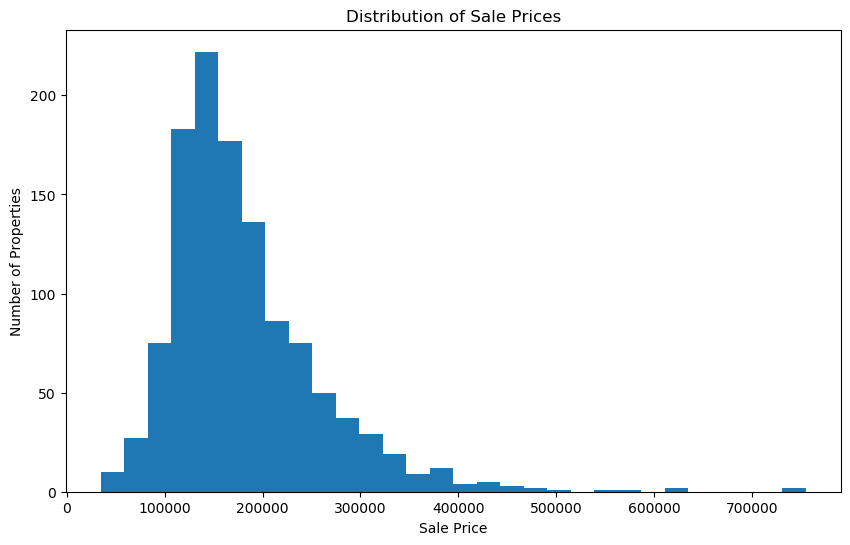

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(y, bins=30)
plt.xlabel("Sale Price")
plt.ylabel("Number of Properties")
plt.title("Distribution of Sale Prices")
plt.show()

## 4.2 Correlation Analysis

Pearson correlation is used to examine the linear relationship between numerical variables and `SalePrice`. The strongest positive relationships are observed for `OverallQual`, `GrLivArea`, `GarageCars`, `GarageArea`, `TotalBsmtSF`, `1stFlrSF`, `FullBath`, `TotRmsAbvGrd`, `YearBuilt`, and `YearRemodAdd`.

Correlation indicates association rather than causation, and categorical variables are not represented by this numerical correlation analysis.


In [18]:
# Calculate numerical correlations with SalePrice
numeric_train = train_clean.select_dtypes(include=[np.number])
correlation = numeric_train.corr()["SalePrice"].sort_values(ascending=False)

print("Top 15 features positively correlated with SalePrice:")
print(correlation.head(16))

print("\nTop 10 features negatively correlated with SalePrice:")
print(correlation.tail(10))


Top 15 features positively correlated with SalePrice:
SalePrice       1.000000
OverallQual     0.789185
GrLivArea       0.707300
GarageCars      0.628329
GarageArea      0.619000
TotalBsmtSF     0.595042
1stFlrSF        0.587642
FullBath        0.554988
TotRmsAbvGrd    0.528363
YearBuilt       0.514408
YearRemodAdd    0.507831
GarageYrBlt     0.474346
MasVnrArea      0.466386
Fireplaces      0.459611
BsmtFinSF1      0.362874
LotFrontage     0.341294
Name: SalePrice, dtype: float64

Top 10 features negatively correlated with SalePrice:
3SsnPorch        0.060119
BsmtFinSF2      -0.010151
BsmtHalfBath    -0.011109
MiscVal         -0.013071
LowQualFinSF    -0.032381
YrSold          -0.045508
MSSubClass      -0.060775
OverallCond     -0.065642
EnclosedPorch   -0.115004
KitchenAbvGr    -0.132108
Name: SalePrice, dtype: float64


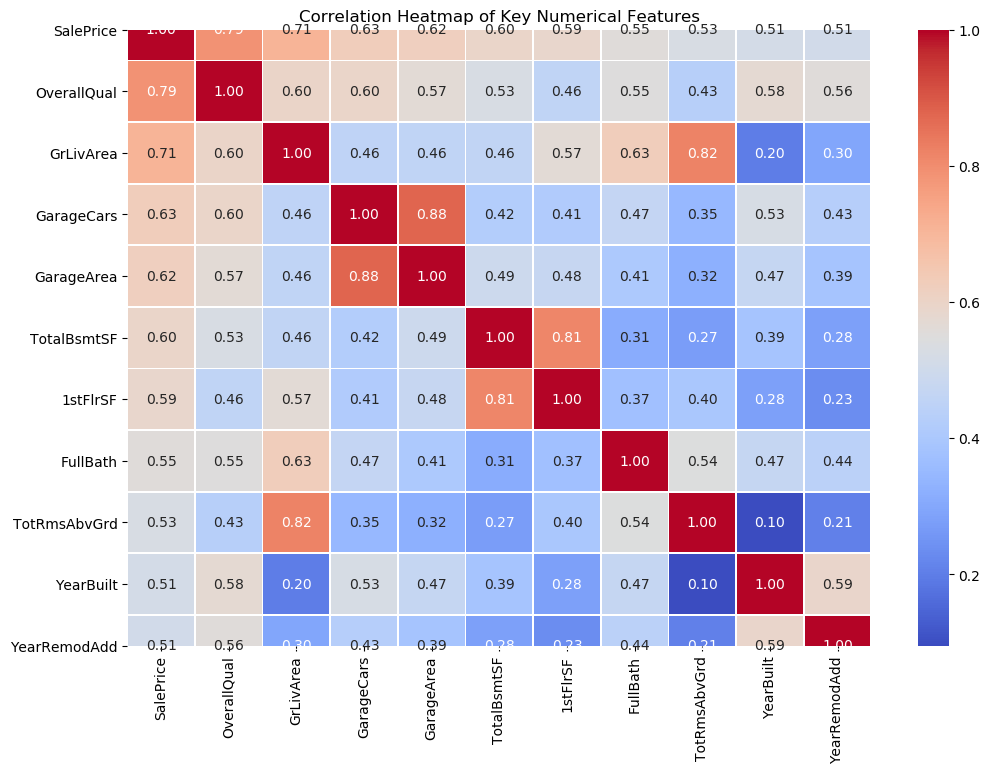

In [20]:
# Select the most important numerical features
top_features = [
    "SalePrice",
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "GarageArea",
    "TotalBsmtSF",
    "1stFlrSF",
    "FullBath",
    "TotRmsAbvGrd",
    "YearBuilt",
    "YearRemodAdd"
]

# Create correlation matrix
corr_matrix = train_clean[top_features].corr()

# Plot heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Key Numerical Features")
plt.show()

## 4.3 Relationships Among Important Predictors

Several predictor variables are strongly correlated with each other. Examples include `GarageCars` and `GarageArea` (approximately 0.88), `GrLivArea` and `TotRmsAbvGrd` (approximately 0.82), and `TotalBsmtSF` and `1stFlrSF` (approximately 0.81).

These relationships indicate overlapping information among some predictors. Regularized linear models can reduce coefficient instability caused by multicollinearity, while tree-based models can capture nonlinear relationships and interactions.


## 4.4 Relationship Between Overall Quality and SalePrice

`OverallQual` rates the overall material and finish of the house on a scale from 1 (very poor) to 10 (very excellent). It has the strongest numerical correlation with `SalePrice` in the training data.

The boxplot below shows how the distribution of sale prices changes across quality levels. Higher quality ratings generally correspond to higher price distributions.


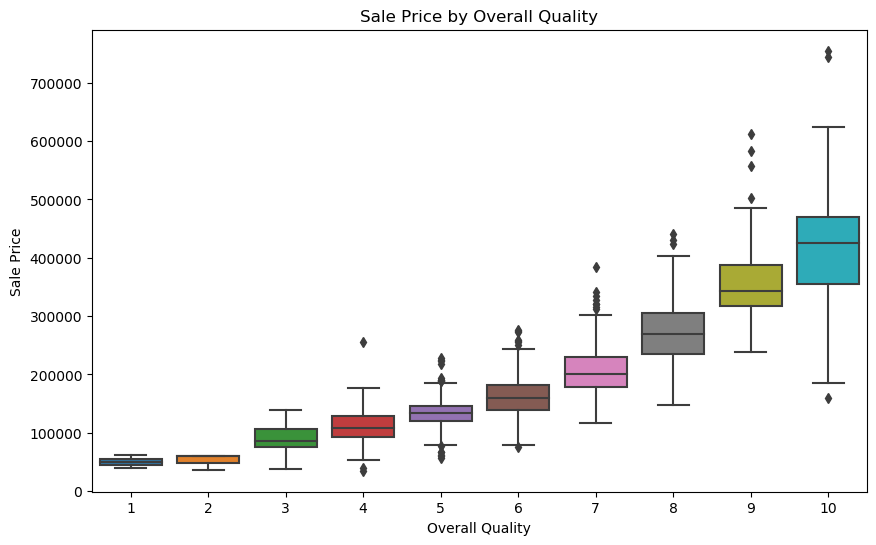

In [21]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    x="OverallQual",
    y="SalePrice",
    data=train_clean
)

plt.xlabel("Overall Quality")
plt.ylabel("Sale Price")
plt.title("Sale Price by Overall Quality")
plt.show()

## 4.5 SalePrice Across Neighborhoods

`Neighborhood` represents the physical location of a property within the Ames city limits. Location is an important real estate characteristic because property values can vary substantially between neighborhoods.

The boxplot below compares sale-price distributions across neighborhoods and demonstrates the predictive value of location-related information.


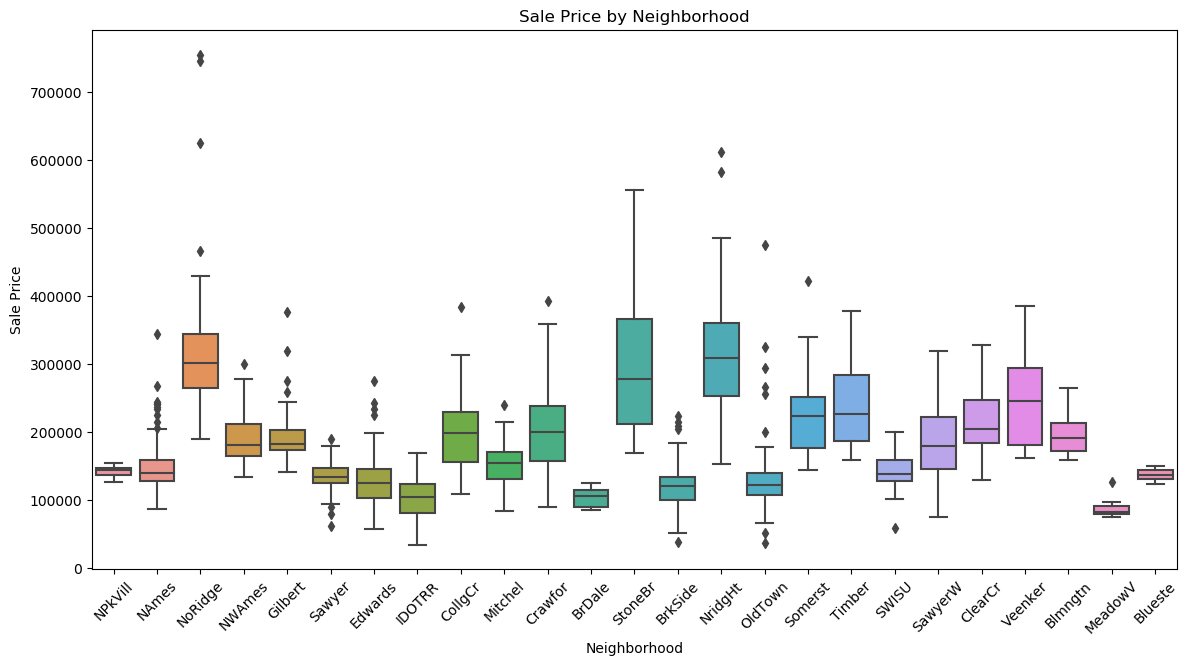

In [22]:
plt.figure(figsize=(14, 7))

sns.boxplot(
    x="Neighborhood",
    y="SalePrice",
    data=train_clean
)

plt.xlabel("Neighborhood")
plt.ylabel("Sale Price")
plt.title("Sale Price by Neighborhood")
plt.xticks(rotation=45)

plt.show()

## 4.6 Relationship Between GrLivArea and SalePrice

`GrLivArea` represents above-ground living area in square feet. The scatter plot is used to examine the relationship between usable living area and sale price. A generally positive relationship is visible, while unusually large or expensive properties can appear as influential observations.


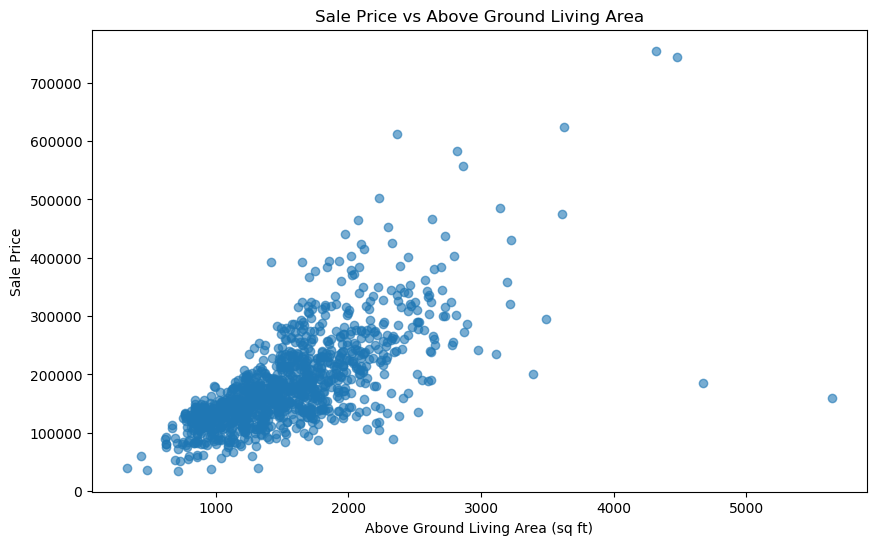

In [23]:
plt.figure(figsize=(10, 6))

plt.scatter(
    train_clean["GrLivArea"],
    train_clean["SalePrice"],
    alpha=0.6
)

plt.xlabel("Above Ground Living Area (sq ft)")
plt.ylabel("Sale Price")
plt.title("Sale Price vs Above Ground Living Area")

plt.show()

## 4.7 Outlier Analysis

Potential outliers are examined using boxplots for important numerical variables including `GrLivArea`, `TotalBsmtSF`, `1stFlrSF`, `GarageArea`, `LotArea`, and `SalePrice`.

Extreme observations are not automatically removed because they may represent genuine properties rather than data errors. Instead, their presence is considered when selecting a robust modeling strategy and transforming the target variable.


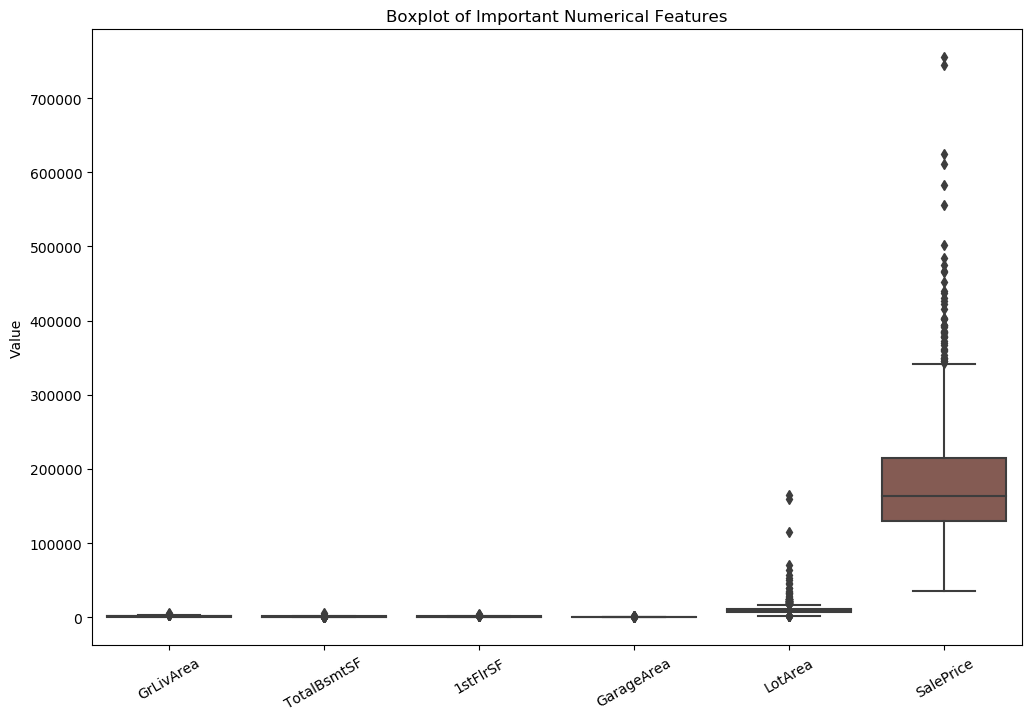

In [24]:
# Check important numerical features for potential outliers

important_features = [
    "GrLivArea",
    "TotalBsmtSF",
    "1stFlrSF",
    "GarageArea",
    "LotArea",
    "SalePrice"
]

plt.figure(figsize=(12, 8))

sns.boxplot(data=train_clean[important_features])

plt.title("Boxplot of Important Numerical Features")
plt.ylabel("Value")
plt.xticks(rotation=30)

plt.show()

## 4.8 EDA Summary

The exploratory analysis produced the following key observations:

1. `SalePrice` is right-skewed, supporting a logarithmic target transformation.
2. `OverallQual` has the strongest correlation with `SalePrice` (approximately 0.789).
3. `GrLivArea` has a strong positive relationship with `SalePrice` (approximately 0.707).
4. `GarageCars`, `GarageArea`, `TotalBsmtSF`, and `1stFlrSF` are important numerical predictors.
5. Sale prices vary substantially across neighborhoods.
6. Several numerical variables contain potential outliers.
7. Some predictors are strongly correlated with one another, indicating overlapping information.

These findings guide target transformation, preprocessing, model selection, and later feature-importance interpretation.


# 5. Feature Engineering

Feature engineering transforms the cleaned dataset into a format suitable for machine learning. In this project, the main steps include identifying numerical and categorical features, applying a logarithmic transformation to the target variable, splitting the data into training and validation sets, and defining preprocessing pipelines for numerical and categorical variables.

## 5.1 Identification of Numerical and Categorical Features

The dataset contains both numerical and categorical variables. Numerical variables represent measurable quantities such as living area, lot area, year built, and number of rooms. Categorical variables represent property characteristics such as neighborhood, house style, exterior material, and garage type.

The numerical and categorical columns are identified separately so that appropriate preprocessing techniques can be applied to each group.

In [25]:
# Identify numerical and categorical features

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Number of numerical features:", len(numerical_features))
print("Number of categorical features:", len(categorical_features))

print("\nNumerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Number of numerical features: 36
Number of categorical features: 43

Numerical features:
['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']

Categorical features:
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 

## 5.2 Target Variable Transformation

SalePrice is the target variable that the model is required to predict. The exploratory analysis showed that SalePrice is right-skewed and contains some high-value observations.

To reduce the effect of this skewness and make the target distribution more suitable for regression modeling, a natural logarithmic transformation is applied using log1p. The transformation is:

log(SalePrice + 1)

The +1 component allows the transformation to safely handle zero values.

In [26]:
from sklearn.model_selection import train_test_split
import numpy as np

# Log transform the target variable
y_log = np.log1p(y)

# Split the dataset
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y_log,
    test_size=0.20,
    random_state=42
)

print("Training feature shape:", X_train.shape)
print("Validation feature shape:", X_valid.shape)

print("Training target shape:", y_train.shape)
print("Validation target shape:", y_valid.shape)

Training feature shape: (934, 79)
Validation feature shape: (234, 79)
Training target shape: (934,)
Validation target shape: (234,)


## 5.3 Training and Validation Split

The cleaned dataset is divided into training and validation subsets. An 80:20 split is used with `random_state=42` so that the experiment is reproducible. The training subset is used to fit models, while the validation subset is reserved for performance evaluation on unseen observations.


## 5.4 Numerical and Categorical Preprocessing

Machine-learning algorithms require numerical input. Therefore, the numerical and categorical variables are processed separately.

Numerical features are standardized using StandardScaler so that their values are placed on a comparable scale.

Categorical features are converted into numerical form using OneHotEncoder. The option handle_unknown="ignore" ensures that previously unseen categories in validation or test data do not cause errors during prediction.

A ColumnTransformer is used to apply the appropriate transformation to each feature group.

In [27]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Preprocessing for numerical features
numeric_transformer = StandardScaler()

# Preprocessing for categorical features
categorical_transformer = OneHotEncoder(
    handle_unknown="ignore"
)

# Combine both preprocessing methods
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")
print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))

Preprocessing pipeline created successfully!
Numerical features: 36
Categorical features: 43


## 5.5 Feature Engineering Summary

The feature engineering stage prepared the dataset for machine-learning model development. The 79 predictor variables were separated into numerical and categorical groups. Numerical variables were standardized using StandardScaler, while categorical variables were converted using OneHotEncoder. The SalePrice target was log-transformed to reduce skewness. Finally, the data was divided into training and validation sets using an 80:20 split with a fixed random state of 42.

The resulting preprocessing pipeline ensures that the same transformations can be consistently applied during model training, validation, and final test prediction.

# 6. Model Selection and Training

Multiple regression models are trained and compared to identify the most suitable approach for predicting residential property prices. Linear Regression provides a baseline, Ridge and Lasso introduce regularization, and Random Forest and Gradient Boosting provide nonlinear ensemble approaches.

All models use the same preprocessing framework and the same train-validation split so that the comparison is consistent.


## 6.1 Model Evaluation Approach

The initial comparison includes five regression algorithms:

1. Linear Regression
2. Ridge Regression
3. Lasso Regression
4. Random Forest Regression
5. Gradient Boosting Regression

The models are evaluated using Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R². Lower RMSE indicates smaller prediction errors, while higher R² indicates that the model explains more of the variation in the target.


## 6.2 Linear Regression

Linear Regression is used as the baseline model. It assumes a linear relationship between the transformed target and the predictor variables and provides a benchmark for assessing the benefit of regularization and nonlinear ensemble methods.


In [28]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

# Create Linear Regression pipeline
linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

# Train the model
linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [29]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Make predictions on validation data
linear_pred_log = linear_model.predict(X_valid)

# Convert predictions back to original price scale
linear_pred = np.expm1(linear_pred_log)

# Convert actual validation values back to original price scale
y_valid_original = np.expm1(y_valid)

# Calculate metrics
linear_mse = mean_squared_error(y_valid_original, linear_pred)
linear_rmse = np.sqrt(linear_mse)
linear_r2 = r2_score(y_valid_original, linear_pred)

print("Linear Regression Results")
print("-------------------------")
print("MSE  :", linear_mse)
print("RMSE :", linear_rmse)
print("R²   :", linear_r2)

Linear Regression Results
-------------------------
MSE  : 3047744473.613721
RMSE : 55206.380732789585
R²   : 0.5631734779600731


## 6.3 Ridge Regression

Ridge Regression adds an L2 regularization penalty to Linear Regression. This helps control large coefficients and can reduce instability when predictors contain overlapping information. An initial `alpha` value of 10 is used.


In [30]:
from sklearn.linear_model import Ridge

# Create Ridge Regression pipeline
ridge_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=10))
])

# Train the model
ridge_model.fit(X_train, y_train)

print("Ridge Regression model trained successfully!")

Ridge Regression model trained successfully!


In [31]:
# Make predictions
ridge_pred_log = ridge_model.predict(X_valid)

# Convert predictions back to original price scale
ridge_pred = np.expm1(ridge_pred_log)

# Calculate metrics
ridge_mse = mean_squared_error(y_valid_original, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_valid_original, ridge_pred)

print("Ridge Regression Results")
print("------------------------")
print("MSE  :", ridge_mse)
print("RMSE :", ridge_rmse)
print("R²   :", ridge_r2)

Ridge Regression Results
------------------------
MSE  : 1992358970.4176352
RMSE : 44635.84848994847
R²   : 0.7144395643278292


## 6.4 Lasso Regression

Lasso Regression uses L1 regularization, which can shrink some coefficients toward zero and therefore provide a form of feature selection. An initial `alpha` value of 0.0005 is used with a higher iteration limit to support convergence.


In [32]:
from sklearn.linear_model import Lasso

# Create Lasso Regression pipeline
lasso_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Lasso(alpha=0.0005, max_iter=10000))
])

# Train the model
lasso_model.fit(X_train, y_train)

print("Lasso Regression model trained successfully!")

Lasso Regression model trained successfully!


In [33]:
# Make predictions
lasso_pred_log = lasso_model.predict(X_valid)

# Convert predictions back to original price scale
lasso_pred = np.expm1(lasso_pred_log)

# Calculate metrics
lasso_mse = mean_squared_error(y_valid_original, lasso_pred)
lasso_rmse = np.sqrt(lasso_mse)
lasso_r2 = r2_score(y_valid_original, lasso_pred)

print("Lasso Regression Results")
print("------------------------")
print("MSE  :", lasso_mse)
print("RMSE :", lasso_rmse)
print("R²   :", lasso_r2)

Lasso Regression Results
------------------------
MSE  : 2620984962.5989385
RMSE : 51195.55608252477
R²   : 0.624339981437646


## 6.5 Random Forest Regression

Random Forest Regression combines predictions from multiple decision trees. It can model nonlinear relationships and feature interactions without requiring explicit mathematical interaction terms.


In [34]:
from sklearn.ensemble import RandomForestRegressor

# Create Random Forest pipeline
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    ))
])

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")
# Make predictions
rf_pred_log = rf_model.predict(X_valid)

# Convert predictions back to original price scale
rf_pred = np.expm1(rf_pred_log)

# Calculate metrics
rf_mse = mean_squared_error(y_valid_original, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_valid_original, rf_pred)

print("Random Forest Results")
print("---------------------")
print("MSE  :", rf_mse)
print("RMSE :", rf_rmse)
print("R²   :", rf_r2)

Random Forest model trained successfully!
Random Forest Results
---------------------
MSE  : 1652410402.0070617
RMSE : 40649.85119292642
R²   : 0.7631636460534759


## 6.6 Gradient Boosting Regression

Gradient Boosting builds an ensemble sequentially, with each new tree attempting to reduce the errors made by the previous ensemble. This approach is suitable for housing data because relationships between property characteristics and prices can be nonlinear and interactive.


In [35]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        min_samples_leaf=2,
        subsample=0.8,
        random_state=42
    ))
])

gb_model.fit(X_train, y_train)

print("Gradient Boosting model trained successfully!")
gb_pred_log = gb_model.predict(X_valid)

# Convert predictions back to original SalePrice scale
gb_pred = np.expm1(gb_pred_log)

# Calculate evaluation metrics
gb_mse = mean_squared_error(y_valid_original, gb_pred)
gb_rmse = np.sqrt(gb_mse)
gb_r2 = r2_score(y_valid_original, gb_pred)

print("Gradient Boosting Results")
print("------------------------")
print("MSE  :", gb_mse)
print("RMSE :", gb_rmse)
print("R²   :", gb_r2)

Gradient Boosting model trained successfully!
Gradient Boosting Results
------------------------
MSE  : 1308895399.3393831
RMSE : 36178.65944641099
R²   : 0.8123988969686997


## 6.7 Initial Model Comparison

The five initial models are compared using validation RMSE and R². Lower RMSE indicates smaller prediction errors, while higher R² indicates stronger explanatory performance.


In [36]:
# Initial model comparison

model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Lasso Regression",
        "Ridge Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "RMSE": [
        linear_rmse,
        lasso_rmse,
        ridge_rmse,
        rf_rmse,
        gb_rmse
    ],
    "R2": [
        linear_r2,
        lasso_r2,
        ridge_r2,
        rf_r2,
        gb_r2
    ]
})

model_comparison = model_comparison.sort_values(
    by="RMSE",
    ascending=True
).reset_index(drop=True)

print("Initial Model Comparison")
print("------------------------")
display(model_comparison)


Initial Model Comparison
------------------------


,Model,RMSE,R2
0,Gradient Boosting,36178.659446,0.812399
1,Random Forest,40649.851193,0.763164
2,Ridge Regression,44635.848490,0.714440
3,Lasso Regression,51195.556083,0.624340
4,Linear Regression,55206.380733,0.563173


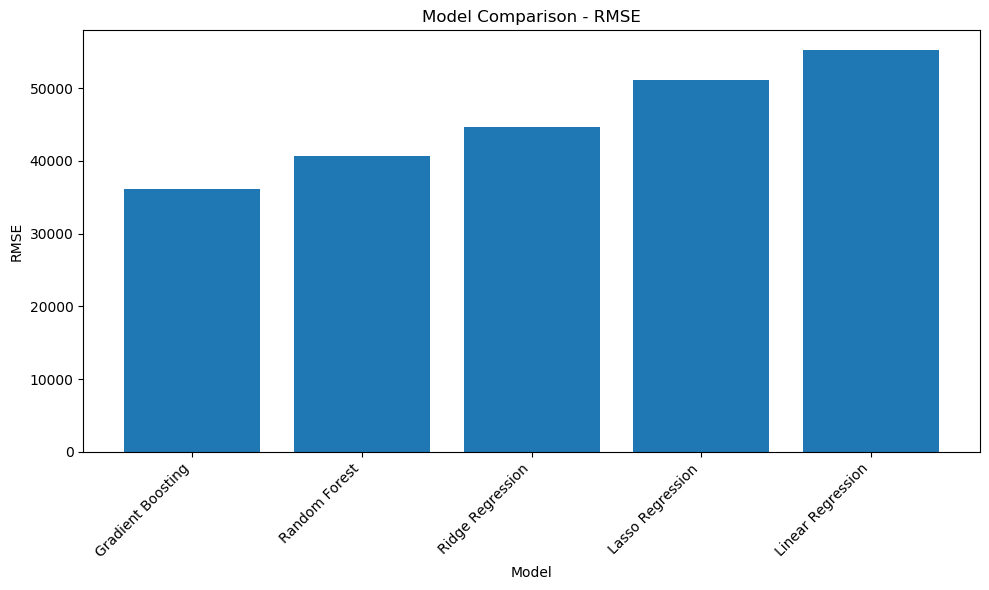

In [37]:
# RMSE comparison

plt.figure(figsize=(10, 6))

plt.bar(
    model_comparison["Model"],
    model_comparison["RMSE"]
)

plt.title("Model Comparison - RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

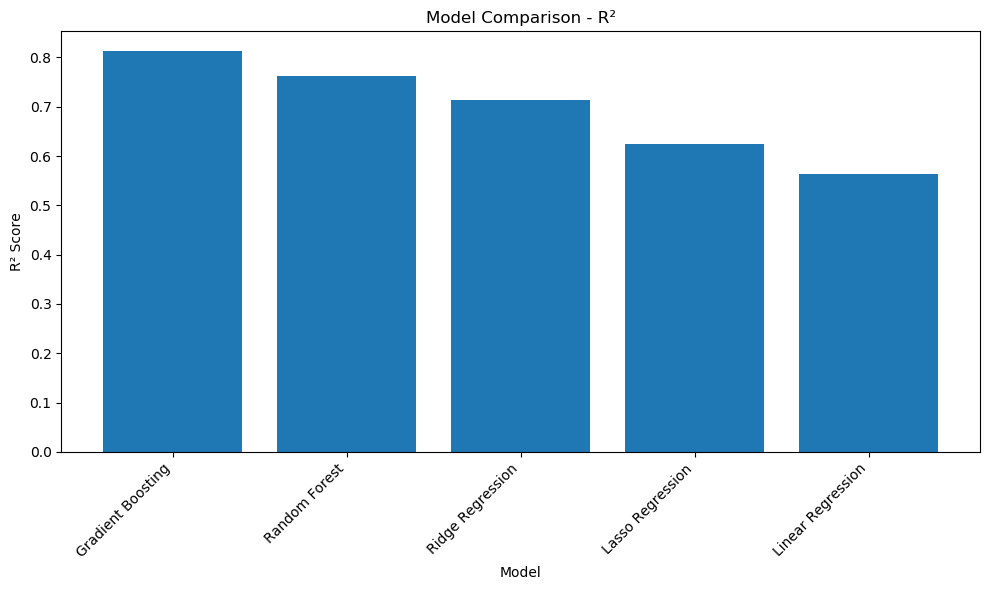

In [38]:
# R² comparison

plt.figure(figsize=(10, 6))

plt.bar(
    model_comparison["Model"],
    model_comparison["R2"]
)

plt.title("Model Comparison - R²")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 6.8 Model Comparison Summary

The initial comparison shows that Gradient Boosting provides the strongest validation performance among the five initial models, achieving an RMSE of approximately 36,178.66 and an R² of approximately 0.8124. Random Forest is the next strongest model, while the linear and regularized linear models produce larger errors.

Because Gradient Boosting performs best in the initial comparison, it is selected for hyperparameter tuning in the next section.


# 7. Hyperparameter Tuning

Hyperparameter tuning is performed to improve the initial Gradient Boosting model. Grid Search with 5-fold cross-validation is used to evaluate a controlled set of hyperparameter combinations using negative mean squared error on the log-transformed target.


## 7.1 Hyperparameters Considered

The tuning process considers:

- `n_estimators`: number of boosting stages.
- `learning_rate`: contribution of each boosting stage.
- `max_depth`: maximum depth of each tree.
- `min_samples_leaf`: minimum number of samples in a leaf.
- `subsample`: fraction of observations used at each boosting stage.


## 7.2 Parameter Grid

A controlled grid containing 32 parameter combinations is used. With 5-fold cross-validation, the search evaluates 160 model fits. `n_jobs=1` is used for stability in the current Python environment.


## 7.3 Grid Search with Cross-Validation

Each hyperparameter combination is evaluated using 5-fold cross-validation on the training portion of the data. Scikit-learn represents the minimization of mean squared error as a negative score, so a less-negative value corresponds to a lower cross-validated MSE.


In [39]:
from sklearn.model_selection import GridSearchCV

# Gradient Boosting pipeline
gb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(random_state=42))
])

# Smaller and safer parameter grid
gb_param_grid = {
    "model__n_estimators": [200, 300],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3],
    "model__min_samples_leaf": [2, 4],
    "model__subsample": [0.8, 1.0]
}

# Grid Search
gb_grid = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=gb_param_grid,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=1,
    verbose=1
)

# Train
gb_grid.fit(X_train, y_train)

print("Gradient Boosting hyperparameter tuning completed!")
print("Best parameters:")
print(gb_grid.best_params_)
print("Best CV score:", gb_grid.best_score_)

Fitting 5 folds for each of 32 candidates, totalling 160 fits


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:   37.0s


Gradient Boosting hyperparameter tuning completed!
Best parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__min_samples_leaf': 2, 'model__n_estimators': 200, 'model__subsample': 0.8}
Best CV score: -0.01856217742684521


In [40]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Get the best tuned Gradient Boosting model
best_gb_model = gb_grid.best_estimator_

# Predict on validation data
best_gb_pred_log = best_gb_model.predict(X_valid)

# Convert predictions back to original SalePrice scale
best_gb_pred = np.expm1(best_gb_pred_log)

# Convert actual validation target back to original scale
y_valid_original = np.expm1(y_valid)

# Calculate evaluation metrics
best_gb_mse = mean_squared_error(y_valid_original, best_gb_pred)
best_gb_rmse = np.sqrt(best_gb_mse)
best_gb_r2 = r2_score(y_valid_original, best_gb_pred)

print("Tuned Gradient Boosting Results")
print("--------------------------------")
print("MSE :", best_gb_mse)
print("RMSE:", best_gb_rmse)
print("R²  :", best_gb_r2)

Tuned Gradient Boosting Results
--------------------------------
MSE : 1263010426.782848
RMSE: 35538.85798366132
R²  : 0.8189754893140555


## 7.4 Best Hyperparameters

The best configuration identified by Grid Search is:

- `n_estimators = 200`
- `learning_rate = 0.1`
- `max_depth = 3`
- `min_samples_leaf = 2`
- `subsample = 0.8`

This configuration is selected for final validation and for training the final model on the complete training dataset.


## 7.5 Evaluation of the Tuned Gradient Boosting Model

On the validation dataset, the tuned Gradient Boosting model achieves:

- **MSE:** 1,263,010,426.78
- **RMSE:** 35,538.86
- **R²:** 0.8190

The RMSE is measured on the original SalePrice scale after reversing the logarithmic transformation.


## 7.6 Performance Before and After Hyperparameter Tuning

Before tuning, Gradient Boosting achieved an RMSE of 36,178.66 and an R² of 0.8124. After tuning, RMSE decreased to 35,538.86 and R² increased to 0.8190.

This improvement indicates that the selected hyperparameter configuration provides better validation performance than the initial Gradient Boosting configuration.


## 7.7 Hyperparameter Tuning Summary

The tuning process improved the predictive performance of Gradient Boosting and produced the final model configuration used for subsequent evaluation and test prediction.


# 8. Model Evaluation

The tuned Gradient Boosting model is evaluated in greater detail using validation metrics and diagnostic visualizations. The analysis considers prediction accuracy, prediction errors, and residual behavior.


## 8.1 Final Validation Metrics

The tuned model achieves an MSE of 1,263,010,426.78, an RMSE of 35,538.86, an R² of 0.8190, and an MAE of 18,443.15 on the validation set. An R² of approximately 0.819 indicates that the model explains about 81.9% of the variation in validation sale prices.


## 8.2 Actual vs Predicted SalePrice

The actual-versus-predicted plot compares observed sale prices with model predictions. Points closer to the diagonal reference line represent smaller prediction errors. The plot provides a visual check of how closely predictions follow the observed values across the price range.


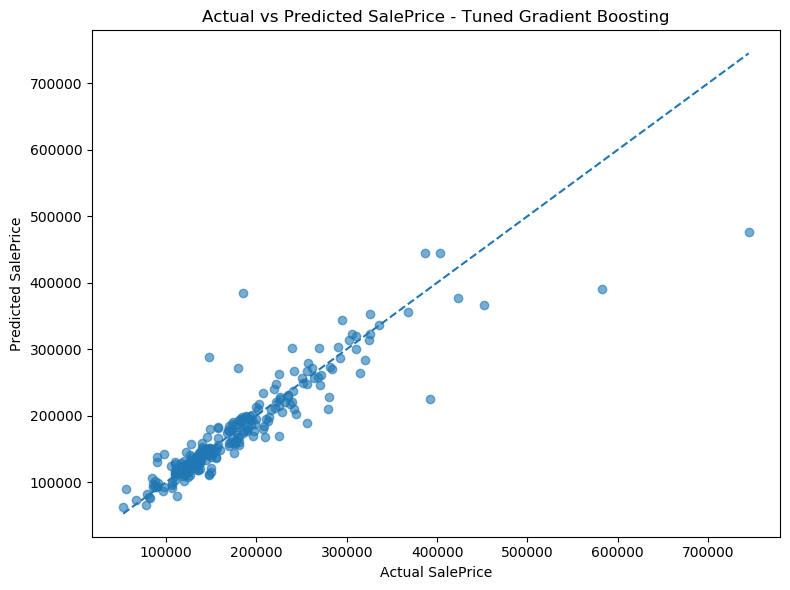

In [41]:
# Actual vs Predicted SalePrice

plt.figure(figsize=(8, 6))

plt.scatter(
    y_valid_original,
    best_gb_pred,
    alpha=0.6
)

# Perfect prediction reference line
min_price = min(y_valid_original.min(), best_gb_pred.min())
max_price = max(y_valid_original.max(), best_gb_pred.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.title("Actual vs Predicted SalePrice - Tuned Gradient Boosting")
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.tight_layout()
plt.show()

## 8.3 Prediction Error Analysis

Prediction error is defined as:

**Error = Actual SalePrice − Predicted SalePrice**

A positive error means the model underpredicted the property price, while a negative error means the model overpredicted it. The mean absolute error summarizes the average magnitude of the prediction errors without considering their direction.


In [42]:
# Calculate prediction errors

prediction_errors = y_valid_original - best_gb_pred

print("Prediction Error Statistics")
print("---------------------------")
print("Mean Error:", prediction_errors.mean())
print("Minimum Error:", prediction_errors.min())
print("Maximum Error:", prediction_errors.max())
print("Mean Absolute Error:", np.mean(np.abs(prediction_errors)))

Prediction Error Statistics
---------------------------
Mean Error: 2611.8422660779115
Minimum Error: -200077.37123222928
Maximum Error: 268179.8904021526
Mean Absolute Error: 18443.149115362397


## 8.4 Residual Analysis

Residuals are the differences between actual and predicted prices. A residual plot is used to check whether errors are reasonably distributed around zero without a strong systematic pattern. Large residuals identify observations for which the model has greater difficulty producing accurate estimates.


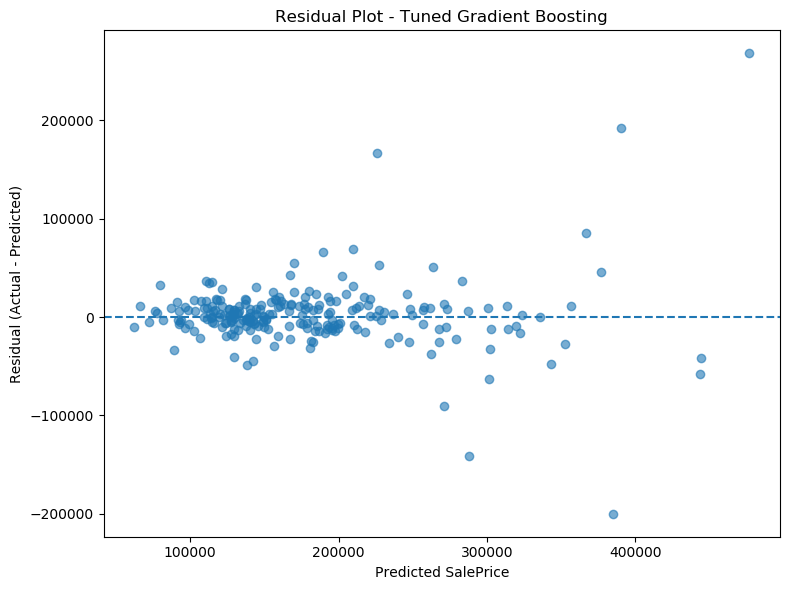

In [43]:
# Residual plot

plt.figure(figsize=(8, 6))

plt.scatter(
    best_gb_pred,
    prediction_errors,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Residual Plot - Tuned Gradient Boosting")
plt.xlabel("Predicted SalePrice")
plt.ylabel("Residual (Actual - Predicted)")
plt.tight_layout()
plt.show()

## 8.5 Overall Model Performance Comparison

| Model | RMSE | R² |
|---|---:|---:|
| Linear Regression | 55,206.38 | 0.5632 |
| Lasso Regression | 51,195.56 | 0.6243 |
| Ridge Regression | 44,635.85 | 0.7144 |
| Random Forest | 40,649.85 | 0.7632 |
| Gradient Boosting | 36,178.66 | 0.8124 |
| Tuned Gradient Boosting | 35,538.86 | 0.8190 |

The tuned Gradient Boosting model achieves the lowest RMSE and highest R² among the evaluated models.


## 8.6 Model Evaluation Summary

The tuned Gradient Boosting Regressor provides the strongest validation performance. Its RMSE of approximately 35.5K indicates substantially smaller errors than the linear and other ensemble alternatives evaluated in this project. The results support its selection as the final predictive model.


# 9. Feature Importance Analysis

Feature importance analysis is performed to understand which property characteristics contribute most strongly to the predictions made by the tuned Gradient Boosting model. This analysis supports business interpretation by highlighting the variables that deserve attention during property evaluation.


## 9.1 Gradient Boosting Feature Importance

The fitted Gradient Boosting model provides an importance score for each transformed feature. These scores represent the relative contribution of features to the model's predictive decisions.


In [45]:
# Extract the fitted preprocessor and Gradient Boosting model

fitted_preprocessor = best_gb_model.named_steps["preprocessor"]
gb_final_model = best_gb_model.named_steps["model"]

# Get encoded categorical feature names
encoder = fitted_preprocessor.named_transformers_["cat"]

cat_feature_names = []

for col, categories in zip(categorical_features, encoder.categories_):
    for category in categories:
        cat_feature_names.append(
            col + "_" + str(category)
        )

# Combine numerical and categorical feature names
feature_names = numerical_features + cat_feature_names

# Get feature importance
feature_importances = gb_final_model.feature_importances_

# Create dataframe
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importances
})

# Sort by importance
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("Top 20 Most Important Features")
print("--------------------------------")
display(importance_df.head(20))

Top 20 Most Important Features
--------------------------------


,Feature,Importance
0,OverallQual,0.472691
1,GrLivArea,0.151039
2,TotalBsmtSF,0.047867
3,GarageArea,0.035495
4,YearRemodAdd,0.031314
5,BsmtFinSF1,0.021154
6,GarageYrBlt,0.020933
7,1stFlrSF,0.018434
8,LotArea,0.017221
9,YearBuilt,0.015419


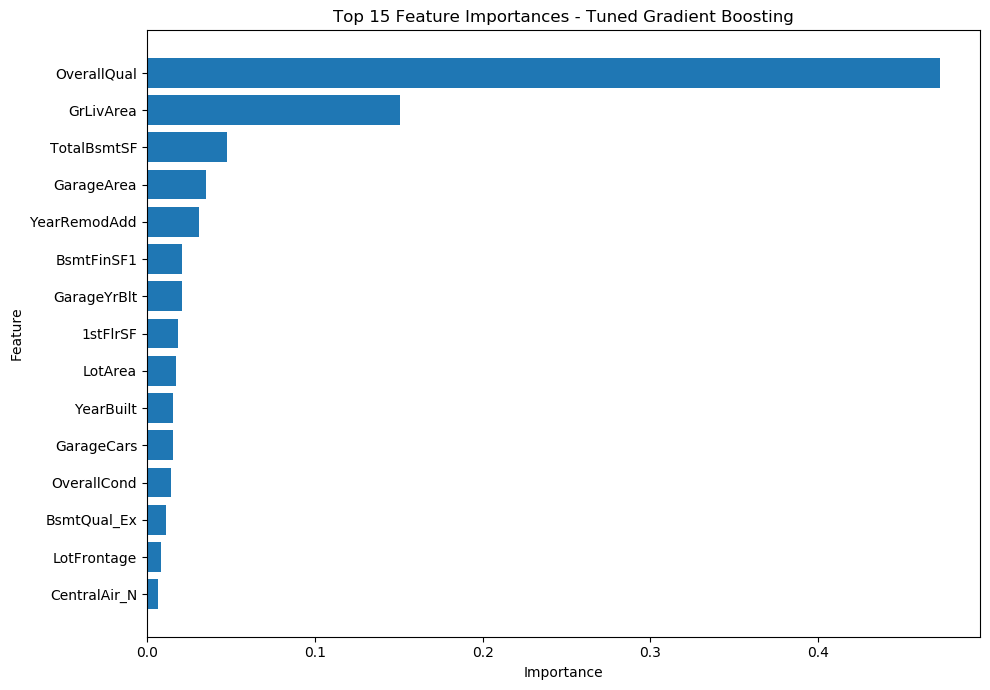

In [46]:
# Plot top 15 features

top_features = importance_df.head(15).sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 15 Feature Importances - Tuned Gradient Boosting")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 9.2 Top Features and Interpretation

The strongest Gradient Boosting feature importances are:

| Feature | Importance |
|---|---:|
| OverallQual | 0.4727 |
| GrLivArea | 0.1510 |
| TotalBsmtSF | 0.0479 |
| GarageArea | 0.0355 |
| YearRemodAdd | 0.0313 |
| BsmtFinSF1 | 0.0212 |
| GarageYrBlt | 0.0209 |
| 1stFlrSF | 0.0184 |
| LotArea | 0.0172 |
| YearBuilt | 0.0154 |

`OverallQual` is by far the most influential feature, followed by `GrLivArea`. This indicates that overall property quality and above-ground living area are especially important to the predictive behavior of the final model.


## 9.3 Positive and Negative Feature Analysis

Ridge Regression coefficients are examined to understand the direction of association between transformed features and the predicted log SalePrice. Positive coefficients indicate a positive model association, while negative coefficients indicate a negative model association, holding the other inputs constant.

These coefficients should not be interpreted as causal effects. One-hot encoded categorical variables, multicollinearity, feature scaling, and category frequency can all affect coefficient magnitude and direction.


In [47]:
# Positive and Negative Feature Analysis using Ridge Regression

# Get the fitted Ridge pipeline
ridge_preprocessor = ridge_model.named_steps["preprocessor"]
ridge_final_model = ridge_model.named_steps["model"]

# Get categorical encoder
ridge_encoder = ridge_preprocessor.named_transformers_["cat"]

# Build categorical feature names
ridge_cat_feature_names = []

for col, categories in zip(categorical_features, ridge_encoder.categories_):
    for category in categories:
        ridge_cat_feature_names.append(
            col + "_" + str(category)
        )

# Combine numerical and categorical feature names
ridge_feature_names = numerical_features + ridge_cat_feature_names

# Get Ridge coefficients
ridge_coefficients = ridge_final_model.coef_

# Create dataframe
coefficient_df = pd.DataFrame({
    "Feature": ridge_feature_names,
    "Coefficient": ridge_coefficients
})

# Sort by coefficient
coefficient_df = coefficient_df.sort_values(
    by="Coefficient",
    ascending=False
).reset_index(drop=True)

print("Top 15 Positive Features")
print("------------------------")
display(coefficient_df.head(15))

print("\nTop 15 Negative Features")
print("------------------------")
display(coefficient_df.tail(15).sort_values(
    by="Coefficient",
    ascending=True
))

Top 15 Positive Features
------------------------


,Feature,Coefficient
0,OverallQual,0.090906
1,Neighborhood_Crawfor,0.086660
2,Neighborhood_StoneBr,0.071251
3,GrLivArea,0.067316
4,Functional_Typ,0.057352
5,Exterior1st_BrkFace,0.053911
6,1stFlrSF,0.053397
7,Neighborhood_Somerst,0.052916
8,MSZoning_RL,0.052801
9,RoofMatl_CompShg,0.052368



Top 15 Negative Features
------------------------


,Feature,Coefficient
291,MSZoning_C (all),-0.111590
290,RoofMatl_ClyTile,-0.097641
289,Neighborhood_IDOTRR,-0.063287
288,SaleCondition_Abnorml,-0.062308
287,Neighborhood_Edwards,-0.057850
286,LotShape_IR3,-0.053396
285,GarageCond_Fa,-0.051699
284,Functional_Maj2,-0.047021
283,BldgType_Twnhs,-0.046514
282,Neighborhood_MeadowV,-0.040789


## 9.4 Feature Importance Summary

The feature importance analysis highlights property quality, living area, basement characteristics, garage characteristics, remodeling year, lot size, and construction year as important components of the predictive framework.

The dominance of `OverallQual` is consistent with its strong correlation with `SalePrice` in the exploratory analysis. These findings can support property screening and valuation, while recognizing that predictive importance does not establish causation.


# 10. Business Implications

The predictive model can be translated into practical applications for property valuation and investment decision support. The model should be used as an analytical aid alongside professional market knowledge rather than as an automatic replacement for expert judgment.


## 10.1 Property Valuation

The final Gradient Boosting model can estimate an expected sale price from the characteristics of a residential property. This provides a quantitative benchmark that can complement traditional valuation methods.


## 10.2 Investment Screening

The model can help screen a large number of properties and prioritize those whose predicted values and characteristics are attractive for further investigation. Properties with strong overall quality and other influential characteristics can be evaluated more closely.


## 10.3 Pricing Strategy

Predicted prices can provide a consistent reference point when setting or reviewing asking prices. Comparing model estimates with observed or proposed prices can also help identify properties that deserve additional analysis.


## 10.4 Renovation and Improvement Opportunities

Feature importance indicates that overall quality and living area are particularly influential. This suggests that improvements affecting property quality or usable living space may be relevant to value assessment. However, the model identifies predictive associations and does not prove that a specific renovation will cause a particular increase in sale price.


## 10.5 Business Recommendations

1. Use the model as a supporting tool for property valuation.
2. Prioritize properties with strong overall quality characteristics during initial screening.
3. Consider living area, basement, garage, construction, and remodeling characteristics together rather than relying on a single variable.
4. Incorporate neighborhood information when comparing properties.
5. Use predicted values to make large-scale property screening more consistent.
6. Combine model predictions with professional market analysis before final investment decisions.
7. Monitor model performance if it is deployed in a changing market.


## 10.6 Limitations

- The supplied observations are from the Ames Housing dataset and may not represent the market in which the business ultimately operates.
- Model performance depends on the quality and distribution of the training data.
- Extreme properties can produce larger prediction errors.
- Feature importance describes model behavior rather than causal impact.
- Market conditions can change over time.
- External factors such as interest rates, economic conditions, regulations, and future development are not directly represented in the available variables.

The model should therefore be treated as a decision-support system and validated on target-market data before production deployment.


# 11. Conclusion and Future Steps

## 11.1 Final Model

After comparing multiple regression algorithms and tuning Gradient Boosting, the tuned Gradient Boosting Regressor was selected as the final model.

**Final configuration:**
- `n_estimators = 200`
- `learning_rate = 0.1`
- `max_depth = 3`
- `min_samples_leaf = 2`
- `subsample = 0.8`

The model achieved a validation RMSE of approximately 35,538.86 and an R² of approximately 0.8190.


## 11.2 Training the Final Model

After validation, the selected Gradient Boosting configuration is retrained using the complete training dataset. This allows the final model to learn from all available labeled observations before predictions are generated for unseen test properties.


In [48]:
# Step 26: Train final Gradient Boosting model on all training data

final_gb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=3,
        min_samples_leaf=2,
        subsample=0.8,
        random_state=42
    ))
])

# Train using the complete training dataset
final_gb_model.fit(X, y_log)

print("Final Gradient Boosting model trained successfully!")
print("Training samples used:", X.shape[0])
print("Features used:", X.shape[1])

Final Gradient Boosting model trained successfully!
Training samples used: 1168
Features used: 79


## 11.3 Generating Test Predictions

The trained final model is applied to the test dataset. Because the target was trained on the `log1p(SalePrice)` scale, the predictions are converted back to the original price scale using the inverse `expm1` transformation.


In [49]:
# Step 27: Generate predictions for the test dataset

test_pred_log = final_gb_model.predict(test_clean)

# Convert predictions back to original SalePrice scale
test_predictions = np.expm1(test_pred_log)

# Ensure predictions are non-negative
test_predictions = np.maximum(test_predictions, 0)

print("Test predictions generated successfully!")
print("Number of predictions:", len(test_predictions))

print("\nFirst 10 predictions:")
print(test_predictions[:10])

Test predictions generated successfully!
Number of predictions: 292

First 10 predictions:
[375757.40425172 194006.93988033 248116.87279833 206139.36895435
 195970.01767162  75035.88495874 133301.36258555 316957.31362835
 228538.07263184 170133.31169235]


## 11.4 Final Prediction File

The test predictions are combined with the original property IDs and saved to `../Outputs/predictions.csv`. The file contains 292 rows and two columns: `Id` and `SalePrice`.


In [50]:
# Step 28: Create final predictions file

predictions_df = pd.DataFrame({
    "Id": test_ids,
    "SalePrice": test_predictions
})

# Save predictions
output_path = "../Outputs/predictions.csv"

predictions_df.to_csv(
    output_path,
    index=False
)

print("Predictions file saved successfully!")
print("File location:", output_path)

display(predictions_df.head(10))

Predictions file saved successfully!
File location: ../Outputs/predictions.csv


,Id,SalePrice
0,337,375757.404252
1,1018,194006.939880
2,929,248116.872798
3,1148,206139.368954
4,1227,195970.017672
5,650,75035.884959
6,1453,133301.362586
7,152,316957.313628
8,427,228538.072632
9,776,170133.311692


## 11.5 Final Model Summary and Verification

The selected model, tuned hyperparameters, validation performance, number of test predictions, and the saved prediction file are summarized and verified below.


In [51]:
# Final selected model summary

print("FINAL SELECTED MODEL")
print("--------------------")
print("Model: Tuned Gradient Boosting Regressor")
print("RMSE:", round(best_gb_rmse, 2))
print("R²:", round(best_gb_r2, 4))

print("\nBest Hyperparameters:")
print("n_estimators:", 200)
print("learning_rate:", 0.1)
print("max_depth:", 3)
print("min_samples_leaf:", 2)
print("subsample:", 0.8)

print("\nFinal test predictions:", len(test_predictions))

FINAL SELECTED MODEL
--------------------
Model: Tuned Gradient Boosting Regressor
RMSE: 35538.86
R²: 0.819

Best Hyperparameters:
n_estimators: 200
learning_rate: 0.1
max_depth: 3
min_samples_leaf: 2
subsample: 0.8

Final test predictions: 292


In [52]:
# Verify final predictions file

final_predictions = pd.read_csv("../Outputs/predictions.csv")

print("Prediction file verification")
print("----------------------------")
print("Rows:", final_predictions.shape[0])
print("Columns:", final_predictions.shape[1])
print("Column names:", list(final_predictions.columns))

print("\nMissing values:")
print(final_predictions.isnull().sum())

print("\nPrediction statistics:")
print(final_predictions["SalePrice"].describe())

print("\nFirst 10 predictions:")
display(final_predictions.head(10))

Prediction file verification
----------------------------
Rows: 292
Columns: 2
Column names: ['Id', 'SalePrice']

Missing values:
Id           0
SalePrice    0
dtype: int64

Prediction statistics:
count       292.000000
mean     175636.790491
std       72592.157905
min       57746.836077
25%      129554.252052
50%      158216.863266
75%      198152.965949
max      464160.113715
Name: SalePrice, dtype: float64

First 10 predictions:


,Id,SalePrice
0,337,375757.404252
1,1018,194006.939880
2,929,248116.872798
3,1148,206139.368954
4,1227,195970.017672
5,650,75035.884959
6,1453,133301.362586
7,152,316957.313628
8,427,228538.072632
9,776,170133.311692


## 11.6 Future Improvements

Future work could improve the predictive framework by:

1. Testing additional algorithms such as XGBoost or LightGBM where the environment permits.
2. Performing broader hyperparameter optimization with careful computational controls.
3. Engineering additional domain-specific features.
4. Evaluating robust outlier-handling strategies.
5. Exploring ensemble or stacking approaches.
6. Evaluating the model on data from the actual target market before deployment.
7. Incorporating economic, geographic, and market-level variables where available.
8. Monitoring model drift and prediction accuracy over time.


## 11.7 Conclusion

This project developed an end-to-end machine learning framework for residential property price prediction. The workflow covered data cleaning, exploratory analysis, feature preparation, comparison of five regression approaches, hyperparameter tuning, detailed model evaluation, feature importance analysis, business interpretation, and final prediction generation.

Gradient Boosting produced the strongest initial validation performance, and hyperparameter tuning improved it further. The final tuned model achieved an RMSE of approximately 35,538.86 and an R² of approximately 0.8190 on the validation data.

Feature importance analysis identified `OverallQual` and `GrLivArea` as particularly influential, together with basement, garage, remodeling, lot, and construction-related variables.

The final model was retrained on all available training observations and used to generate predictions for the 292 test properties. Overall, the project demonstrates how machine learning can support data-driven property valuation and investment screening while emphasizing the need to validate the framework against the characteristics of the market in which it will ultimately be deployed.
